In [ ]:
# Plot 2B: Continental Site Timeseries Analysis
# Three-row subplot: full timeseries, July 1-5 zoom, lapse rate calculations

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Get temperature data for continental sites
continental_sites_data = {}
if continental_highest:
    continental_sites_data['highest'] = ds_hourly.where(ds_hourly.site_id == continental_highest, drop=True).temp_c.mean('sensor_idx')
if continental_middle:
    continental_sites_data['middle'] = ds_hourly.where(ds_hourly.site_id == continental_middle, drop=True).temp_c.mean('sensor_idx')  
if continental_lowest:
    continental_sites_data['lowest'] = ds_hourly.where(ds_hourly.site_id == continental_lowest, drop=True).temp_c.mean('sensor_idx')

# Row 1: Full timeseries
ax1 = axes[0]
colors = {'highest': 'darkblue', 'middle': 'skyblue', 'lowest': 'lightblue'}
for level, temp_data in continental_sites_data.items():
    if level == 'highest' and continental_highest:
        label = f'{level} ({continental_highest})'
        elev = site_elev_dict.get(continental_highest, 'Unknown')
        temp_data.plot(ax=ax1, color=colors[level], label=f'{label} - {elev:.0f}m')
    elif level == 'middle' and continental_middle:
        label = f'{level} ({continental_middle})'
        elev = site_elev_dict.get(continental_middle, 'Unknown') 
        temp_data.plot(ax=ax1, color=colors[level], label=f'{label} - {elev:.0f}m')
    elif level == 'lowest' and continental_lowest:
        label = f'{level} ({continental_lowest})'
        elev = site_elev_dict.get(continental_lowest, 'Unknown')
        temp_data.plot(ax=ax1, color=colors[level], label=f'{label} - {elev:.0f}m')

ax1.set_title('Continental Sites Temperature Timeseries - Full Period')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Row 2: July 1-5 zoom
ax2 = axes[1]
for level, temp_data in continental_sites_data.items():
    if level == 'highest' and continental_highest:
        label = f'{level} ({continental_highest})'
        elev = site_elev_dict.get(continental_highest, 'Unknown')
        temp_data.sel(datetime=july_slice).plot(ax=ax2, color=colors[level], label=f'{label} - {elev:.0f}m', marker='o', markersize=3)
    elif level == 'middle' and continental_middle:
        label = f'{level} ({continental_middle})'
        elev = site_elev_dict.get(continental_middle, 'Unknown')
        temp_data.sel(datetime=july_slice).plot(ax=ax2, color=colors[level], label=f'{label} - {elev:.0f}m', marker='o', markersize=3)
    elif level == 'lowest' and continental_lowest:
        label = f'{level} ({continental_lowest})'
        elev = site_elev_dict.get(continental_lowest, 'Unknown')
        temp_data.sel(datetime=july_slice).plot(ax=ax2, color=colors[level], label=f'{label} - {elev:.0f}m', marker='o', markersize=3)

ax2.set_title('Continental Sites Temperature - First 5 Days of July')
ax2.set_ylabel('Temperature (°C)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Row 3: Lapse rate calculations for July 1-5
ax3 = axes[2]

# 1. Whole-group continental lapse rate (from existing calculation)
continental_july_lapse = ds_hourly.continental_lapse_rate.sel(datetime=july_slice) * 1000
continental_july_lapse.plot(ax=ax3, color='blue', label='All continental sites regression', linewidth=2, alpha=0.8)

# 2. Pairwise lapse rates
if continental_highest and continental_lowest:
    lapse_high_low = calculate_pairwise_lapse_rate(july_ds, continental_highest, continental_lowest) * 1000
    lapse_high_low.plot(ax=ax3, color='red', label=f'{continental_highest}-{continental_lowest}', marker='o', markersize=4)

if continental_highest and continental_middle:
    lapse_high_mid = calculate_pairwise_lapse_rate(july_ds, continental_highest, continental_middle) * 1000  
    lapse_high_mid.plot(ax=ax3, color='orange', label=f'{continental_highest}-{continental_middle}', marker='s', markersize=4)

if continental_middle and continental_lowest:
    lapse_mid_low = calculate_pairwise_lapse_rate(july_ds, continental_middle, continental_lowest) * 1000
    lapse_mid_low.plot(ax=ax3, color='green', label=f'{continental_middle}-{continental_lowest}', marker='^', markersize=4)

ax3.set_title('Continental Lapse Rates - First 5 Days of July')
ax3.set_ylabel('Lapse Rate (°C/km)')
ax3.set_xlabel('Time')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Continental sites analysis completed!")

In [ ]:
# Plot 2A: Maritime Site Timeseries Analysis 
# Three-row subplot: full timeseries, July 1-5 zoom, lapse rate calculations

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Define July 1-5 time slice
july_start = pd.Timestamp('2025-07-01')
july_end = pd.Timestamp('2025-07-06')  # Up to but not including July 6
july_slice = slice(july_start, july_end)

# Get temperature data for maritime sites
maritime_sites_data = {}
if maritime_highest:
    maritime_sites_data['highest'] = ds_hourly.where(ds_hourly.site_id == maritime_highest, drop=True).temp_c.mean('sensor_idx')
if maritime_middle: 
    maritime_sites_data['middle'] = ds_hourly.where(ds_hourly.site_id == maritime_middle, drop=True).temp_c.mean('sensor_idx')
if maritime_lowest:
    maritime_sites_data['lowest'] = ds_hourly.where(ds_hourly.site_id == maritime_lowest, drop=True).temp_c.mean('sensor_idx')

# Row 1: Full timeseries
ax1 = axes[0]
colors = {'highest': 'darkred', 'middle': 'orange', 'lowest': 'lightcoral'}
for level, temp_data in maritime_sites_data.items():
    if level == 'highest' and maritime_highest:
        label = f'{level} ({maritime_highest})'
        elev = site_elev_dict.get(maritime_highest, 'Unknown')
        temp_data.plot(ax=ax1, color=colors[level], label=f'{label} - {elev:.0f}m')
    elif level == 'middle' and maritime_middle:
        label = f'{level} ({maritime_middle})'
        elev = site_elev_dict.get(maritime_middle, 'Unknown')
        temp_data.plot(ax=ax1, color=colors[level], label=f'{label} - {elev:.0f}m')
    elif level == 'lowest' and maritime_lowest:
        label = f'{level} ({maritime_lowest})'
        elev = site_elev_dict.get(maritime_lowest, 'Unknown')
        temp_data.plot(ax=ax1, color=colors[level], label=f'{label} - {elev:.0f}m')

ax1.set_title('Maritime Sites Temperature Timeseries - Full Period')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Row 2: July 1-5 zoom
ax2 = axes[1]
for level, temp_data in maritime_sites_data.items():
    if level == 'highest' and maritime_highest:
        label = f'{level} ({maritime_highest})'
        elev = site_elev_dict.get(maritime_highest, 'Unknown')
        temp_data.sel(datetime=july_slice).plot(ax=ax2, color=colors[level], label=f'{label} - {elev:.0f}m', marker='o', markersize=3)
    elif level == 'middle' and maritime_middle:
        label = f'{level} ({maritime_middle})'
        elev = site_elev_dict.get(maritime_middle, 'Unknown')
        temp_data.sel(datetime=july_slice).plot(ax=ax2, color=colors[level], label=f'{label} - {elev:.0f}m', marker='o', markersize=3)
    elif level == 'lowest' and maritime_lowest:
        label = f'{level} ({maritime_lowest})'
        elev = site_elev_dict.get(maritime_lowest, 'Unknown')
        temp_data.sel(datetime=july_slice).plot(ax=ax2, color=colors[level], label=f'{label} - {elev:.0f}m', marker='o', markersize=3)

ax2.set_title('Maritime Sites Temperature - First 5 Days of July')
ax2.set_ylabel('Temperature (°C)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Row 3: Lapse rate calculations for July 1-5
ax3 = axes[2]

# Calculate different lapse rates for the July period
july_ds = ds_hourly.sel(datetime=july_slice)

# 1. Whole-group maritime lapse rate (from existing calculation)
maritime_july_lapse = ds_hourly.maritime_lapse_rate.sel(datetime=july_slice) * 1000
maritime_july_lapse.plot(ax=ax3, color='blue', label='All maritime sites regression', linewidth=2, alpha=0.8)

# 2. Pairwise lapse rates
if maritime_highest and maritime_lowest:
    lapse_high_low = calculate_pairwise_lapse_rate(july_ds, maritime_highest, maritime_lowest) * 1000
    lapse_high_low.plot(ax=ax3, color='red', label=f'{maritime_highest}-{maritime_lowest}', marker='o', markersize=4)

if maritime_highest and maritime_middle:
    lapse_high_mid = calculate_pairwise_lapse_rate(july_ds, maritime_highest, maritime_middle) * 1000
    lapse_high_mid.plot(ax=ax3, color='orange', label=f'{maritime_highest}-{maritime_middle}', marker='s', markersize=4)

if maritime_middle and maritime_lowest:
    lapse_mid_low = calculate_pairwise_lapse_rate(july_ds, maritime_middle, maritime_lowest) * 1000
    lapse_mid_low.plot(ax=ax3, color='green', label=f'{maritime_middle}-{maritime_lowest}', marker='^', markersize=4)

ax3.set_title('Maritime Lapse Rates - First 5 Days of July')
ax3.set_ylabel('Lapse Rate (°C/km)')
ax3.set_xlabel('Time')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Maritime sites analysis completed!")

In [ ]:
# Plot 1: Histogram Analysis of Lapse Rates
# Two-row subplot: overlapping histograms (top), difference histogram (bottom)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Convert lapse rates to °C/km for better readability
maritime_lapse_km = ds_hourly.maritime_lapse_rate * 1000
continental_lapse_km = ds_hourly.continental_lapse_rate * 1000
lapse_difference_km = maritime_lapse_km - continental_lapse_km

# Remove NaN values for histogram calculation
maritime_clean = maritime_lapse_km.dropna()
continental_clean = continental_lapse_km.dropna()
difference_clean = lapse_difference_km.dropna()

# Calculate statistics
mar_mean = float(maritime_clean.mean())
mar_std = float(maritime_clean.std())
cont_mean = float(continental_clean.mean())
cont_std = float(continental_clean.std())
diff_mean = float(difference_clean.mean())
diff_std = float(difference_clean.std())

# Top row: Overlapping histograms
ax1 = axes[0]
ax1.hist(maritime_clean.values, bins=30, alpha=0.7, color='red', 
         label=f'Maritime (μ={mar_mean:.2f}, σ={mar_std:.2f})')
ax1.hist(continental_clean.values, bins=30, alpha=0.7, color='blue',
         label=f'Continental (μ={cont_mean:.2f}, σ={cont_std:.2f})')
ax1.set_xlabel('Lapse Rate (°C/km)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Lapse Rates: Maritime vs Continental Sites')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom row: Difference histogram  
ax2 = axes[1]
ax2.hist(difference_clean.values, bins=30, alpha=0.7, color='purple',
         label=f'Difference (μ={diff_mean:.2f}, σ={diff_std:.2f})')
ax2.set_xlabel('Lapse Rate Difference (Maritime - Continental, °C/km)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Lapse Rate Differences')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

print(f"Lapse Rate Statistics (°C/km):")
print(f"Maritime: {mar_mean:.3f} ± {mar_std:.3f}")
print(f"Continental: {cont_mean:.3f} ± {cont_std:.3f}")
print(f"Difference (Maritime - Continental): {diff_mean:.3f} ± {diff_std:.3f}")

In [ ]:
# Helper function for pairwise lapse rate calculations
def calculate_pairwise_lapse_rate(ds, site1, site2, time_slice=None):
    """
    Calculate lapse rate between two specific sites for a given time period.
    
    Parameters:
    - ds: xarray dataset with temperature and elevation data
    - site1: first site ID 
    - site2: second site ID
    - time_slice: optional slice object to filter time period
    
    Returns:
    - lapse_rates: xarray DataArray with lapse rates over time (°C/m)
    """
    
    # Apply time slice if provided
    if time_slice is not None:
        ds_subset = ds.sel(datetime=time_slice)
    else:
        ds_subset = ds
    
    # Get data for both sites
    site1_data = ds_subset.where(ds_subset.site_id == site1, drop=True)
    site2_data = ds_subset.where(ds_subset.site_id == site2, drop=True)
    
    # Get temperatures and elevations (take mean if multiple sensors per site)
    temp1 = site1_data.temp_c.mean('sensor_idx')
    temp2 = site2_data.temp_c.mean('sensor_idx')
    elev1 = float(site1_data.elevation.mean().values)
    elev2 = float(site2_data.elevation.mean().values)
    
    # Calculate lapse rate: (T2 - T1) / (elev2 - elev1)
    elev_diff = elev2 - elev1
    if abs(elev_diff) < 1e-6:  # Avoid division by zero
        return xr.full_like(temp1, np.nan)
    
    lapse_rate = (temp2 - temp1) / elev_diff
    
    return lapse_rate

# Test the function
print("Testing pairwise lapse rate calculation...")
if maritime_highest and maritime_lowest:
    test_lapse = calculate_pairwise_lapse_rate(ds_hourly, maritime_highest, maritime_lowest)
    print(f"Test lapse rate between {maritime_highest} and {maritime_lowest}: {test_lapse.mean().values:.6f} °C/m")
    print(f"In °C/km: {test_lapse.mean().values * 1000:.3f} °C/km")

In [ ]:
# Check available sites and their elevations for proper mapping
print("Site mapping and elevation data:")
unique_sites = ds_hourly.site_id.values
unique_elevations = ds_hourly.elevation.values

# Create a site-elevation mapping
site_elev_pairs = list(zip(unique_sites, unique_elevations))
site_elev_dict = {}
for site, elev in site_elev_pairs:
    if site not in site_elev_dict:
        site_elev_dict[site] = elev

print("Available sites with elevations:")
for site in sorted(site_elev_dict.keys()):
    print(f"  {site}: {site_elev_dict[site]:.0f}m")

# Sort maritime and continental sites by elevation
maritime_site_elevs = [(site, site_elev_dict[site]) for site in maritime_sites if site in site_elev_dict]
continental_site_elevs = [(site, site_elev_dict[site]) for site in continental_sites if site in site_elev_dict]

maritime_sorted = sorted(maritime_site_elevs, key=lambda x: x[1], reverse=True)  # High to low
continental_sorted = sorted(continental_site_elevs, key=lambda x: x[1], reverse=True)  # High to low

print("\nMaritime sites (high to low elevation):")
for site, elev in maritime_sorted:
    print(f"  {site}: {elev:.0f}m")

print("\nContinental sites (high to low elevation):")
for site, elev in continental_sorted:
    print(f"  {site}: {elev:.0f}m")

# Define highest, middle, lowest for each group
maritime_highest = maritime_sorted[0][0] if maritime_sorted else None
maritime_middle = maritime_sorted[len(maritime_sorted)//2][0] if len(maritime_sorted) > 1 else None
maritime_lowest = maritime_sorted[-1][0] if maritime_sorted else None

continental_highest = continental_sorted[0][0] if continental_sorted else None
continental_middle = continental_sorted[len(continental_sorted)//2][0] if len(continental_sorted) > 1 else None
continental_lowest = continental_sorted[-1][0] if continental_sorted else None

print(f"\nMaritime group selection:")
print(f"  Highest: {maritime_highest}")
print(f"  Middle: {maritime_middle}")
print(f"  Lowest: {maritime_lowest}")

print(f"\nContinental group selection:")
print(f"  Highest: {continental_highest}")
print(f"  Middle: {continental_middle}")
print(f"  Lowest: {continental_lowest}")

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from jiflr import ROOT

plt.style.use('default')
%matplotlib inline

# Initial Lapse Rate Analysis

Calculate time-varying lapse rates between maritime and continental site groups using lvl1 sensor data. This analysis computes hourly lapse rates over the temporal period where all sites have overlapping data coverage.

In [ ]:
# Load the lvl1 data
lvl1_path = ROOT / 'data' / '2025' / 'processed' / 'lvl1' / 'lvl1_main.nc'
ds = xr.open_dataset(lvl1_path)

print(f"Dataset dimensions: {dict(ds.dims)}")
print(f"Dataset variables: {list(ds.data_vars)}")
print(f"Available site_ids: {sorted(ds.site_id.values.tolist())}")

In [ ]:
# Define site groups based on the available site_ids
# Note: We'll need to map the requested site names to actual site_ids in the dataset

# Maritime sites (as requested): Windward2, Windward1, A04, A05, A06, Divide
# Continental sites (as requested): A07, Lee1, Lee2, A08, A10

# From the data, let's first check what sites are actually available
maritime_sites_requested = ['Windward2', 'Windward1', 'A04', 'A05', 'A06', 'Divide']
continental_sites_requested = ['A07', 'Lee1', 'Lee2', 'A08', 'A10']

# Map to actual site_ids (will need to verify these mappings)
maritime_sites = ['A04', 'A05', 'A06']  # Start with what we know exists
continental_sites = ['A07', 'A08', 'A10']  # Start with what we know exists

print("Requested maritime sites:", maritime_sites_requested)
print("Available maritime sites found:", [s for s in maritime_sites if s in ds.site_id.values])
print("Requested continental sites:", continental_sites_requested)
print("Available continental sites found:", [s for s in continental_sites if s in ds.site_id.values])

# Get the union of all sites needed for analysis
all_analysis_sites = maritime_sites + continental_sites
print(f"All analysis sites: {all_analysis_sites}")

In [ ]:
# Filter the dataset to include only our analysis sites
analysis_mask = ds.site_id.isin(all_analysis_sites)
ds_analysis = ds.where(analysis_mask, drop=True)

print(f"Analysis dataset dimensions: {dict(ds_analysis.dims)}")
print(f"Analysis sites: {sorted(ds_analysis.site_id.values.tolist())}")
print(
    f"Elevation range: {ds_analysis.elevation.min().values:.1f}m to {ds_analysis.elevation.max().values:.1f}m"
)

# Check data availability for each site
print("\nData availability by site:")
for site in sorted(ds_analysis.site_id.values):
    site_data = ds_analysis.where(ds_analysis.site_id == site, drop=True)
    valid_temps = site_data.temp_c.count().values
    total_times = len(ds_analysis.datetime)
    coverage = (valid_temps / total_times) * 100
    elevation = float(site_data.elevation.values[0])
    print(
        f"{site}: {valid_temps:,}/{total_times:,} observations ({coverage:.1f}%) at {elevation:.0f}m"
    )

Analysis dataset dimensions: {'datetime': 18089, 'sensor_idx': 15}
Analysis sites: ['A04', 'A04', 'A05', 'A05', 'A06', 'A06', 'A06', 'A07', 'A07', 'A07', 'A08', 'A08', 'A10', 'A10', 'A10']
Elevation range: 1237.0m to 1825.0m

Data availability by site:
A04: 20,725/18,089 observations (114.6%) at 1237m
A04: 20,725/18,089 observations (114.6%) at 1237m
A05: 23,795/18,089 observations (131.5%) at 1300m
A05: 23,795/18,089 observations (131.5%) at 1300m
A06: 36,474/18,089 observations (201.6%) at 1544m
A06: 36,474/18,089 observations (201.6%) at 1544m
A06: 36,474/18,089 observations (201.6%) at 1544m
A07: 33,115/18,089 observations (183.1%) at 1825m
A07: 33,115/18,089 observations (183.1%) at 1825m
A07: 33,115/18,089 observations (183.1%) at 1825m
A08: 23,593/18,089 observations (130.4%) at 1767m
A08: 23,593/18,089 observations (130.4%) at 1767m
A10: 45,083/18,089 observations (249.2%) at 1476m
A10: 45,083/18,089 observations (249.2%) at 1476m
A10: 45,083/18,089 observations (249.2%) at 147

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_36617/3273757985.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Analysis dataset dimensions: {dict(ds_analysis.dims)}")


In [ ]:
# Define site groups based on the available site_ids
# Note: We'll need to map the requested site names to actual site_ids in the dataset

# Maritime sites (as requested): Windward2, Windward1, A04, A05, A06, Divide
# Continental sites (as requested): A07, Lee1, Lee2, A08, A10

# From the data, let's first check what sites are actually available
maritime_sites_requested = ['Windward2', 'Windward1', 'A04', 'A05', 'A06', 'Divide']
continental_sites_requested = ['A07', 'Lee1', 'Lee2', 'A08', 'A10']

# Map to actual site_ids (will need to verify these mappings)
maritime_sites = ['A04', 'A05', 'A06']  # Start with what we know exists
continental_sites = ['A07', 'A08', 'A10']  # Start with what we know exists

print("Requested maritime sites:", maritime_sites_requested)
print("Available maritime sites found:", [s for s in maritime_sites if s in ds.site_id.values])
print("Requested continental sites:", continental_sites_requested)
print("Available continental sites found:", [s for s in continental_sites if s in ds.site_id.values])

# Get the union of all sites needed for analysis
all_analysis_sites = maritime_sites + continental_sites
print(f"All analysis sites: {all_analysis_sites}")

In [ ]:
# Find the temporal overlap period where ALL analysis sites have valid data
# We'll find the datetime range where all sites have non-NaN temperature data

# For each site, find the first and last valid temperature observation
site_coverage = {}
for site in sorted(ds_analysis.site_id.values):
    site_data = ds_analysis.where(ds_analysis.site_id == site, drop=True)
    temp_data = site_data.temp_c.dropna("datetime")

    if len(temp_data.datetime) > 0:
        first_valid = temp_data.datetime.min()
        last_valid = temp_data.datetime.max()
        site_coverage[site] = {"first": first_valid, "last": last_valid}
        print(
            f"{site}: {pd.to_datetime(first_valid.values)} to {pd.to_datetime(last_valid.values)}"
        )
    else:
        print(f"{site}: No valid data!")
        site_coverage[site] = {"first": None, "last": None}

# Find the overlap period: latest start time to earliest end time
if site_coverage:
    valid_sites = {k: v for k, v in site_coverage.items() if v["first"] is not None}

    if len(valid_sites) >= 2:  # Need at least 2 sites for lapse rate
        overlap_start = max([v["first"] for v in valid_sites.values()])
        overlap_end = min([v["last"] for v in valid_sites.values()])

        print(
            f"\nOverlap period: {pd.to_datetime(overlap_start.values)} to {pd.to_datetime(overlap_end.values)}"
        )

        # Trim dataset to overlap period
        ds_overlap = ds_analysis.sel(datetime=slice(overlap_start, overlap_end))
        print(f"Overlap dataset dimensions: {dict(ds_overlap.dims)}")

        # Verify all sites have data in this period
        print("\nData availability in overlap period:")
        for site in sorted(ds_overlap.site_id.values):
            site_data = ds_overlap.where(ds_overlap.site_id == site, drop=True)
            valid_temps = site_data.temp_c.count().values
            total_times = len(ds_overlap.datetime)
            coverage = (valid_temps / total_times) * 100 if total_times > 0 else 0
            print(
                f"{site}: {valid_temps:,}/{total_times:,} observations ({coverage:.1f}%)"
            )
    else:
        print("Insufficient valid sites for analysis!")
else:
    print("No site coverage data available!")

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_36617/1813577170.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Overlap dataset dimensions: {dict(ds_overlap.dims)}")


A04: 2025-06-21 16:35:00 to 2025-07-27 16:00:00
A04: 2025-06-21 16:35:00 to 2025-07-27 16:00:00
A05: 2025-06-16 16:40:00 to 2025-07-28 00:00:00
A05: 2025-06-16 16:40:00 to 2025-07-28 00:00:00
A06: 2025-06-16 15:50:00 to 2025-07-17 06:55:00
A06: 2025-06-16 15:50:00 to 2025-07-17 06:55:00
A06: 2025-06-16 15:50:00 to 2025-07-17 06:55:00
A07: 2025-06-17 18:15:00 to 2025-07-14 10:10:00
A07: 2025-06-17 18:15:00 to 2025-07-14 10:10:00
A07: 2025-06-17 18:15:00 to 2025-07-14 10:10:00
A08: 2025-06-17 17:30:00 to 2025-07-28 16:25:00
A08: 2025-06-17 17:30:00 to 2025-07-28 16:25:00
A10: 2025-06-17 14:10:00 to 2025-08-08 00:00:00
A10: 2025-06-17 14:10:00 to 2025-08-08 00:00:00
A10: 2025-06-17 14:10:00 to 2025-08-08 00:00:00

Overlap period: 2025-06-21 16:35:00 to 2025-07-14 10:10:00
Overlap dataset dimensions: {'datetime': 6548, 'sensor_idx': 15}

Data availability in overlap period:
A04: 13,096/6,548 observations (200.0%)
A04: 13,096/6,548 observations (200.0%)
A05: 13,096/6,548 observations (200.0

In [ ]:
# Resample to hourly data over the overlap period
print("Resampling to hourly data...")

# Convert datetime to pandas DatetimeIndex for resampling
datetime_pd = pd.to_datetime(ds_overlap.datetime.values)
ds_overlap = ds_overlap.assign_coords(datetime=datetime_pd)

# Resample to 1-hour intervals, taking the mean
ds_hourly = ds_overlap.resample(datetime="1h").mean()

print(f"Hourly dataset dimensions: {dict(ds_hourly.dims)}")
print(f"Original time points: {len(ds_overlap.datetime)}")
print(f"Hourly time points: {len(ds_hourly.datetime)}")
print(
    f"Time range: {ds_hourly.datetime.min().values} to {ds_hourly.datetime.max().values}"
)

Resampling to hourly data...
Hourly dataset dimensions: {'datetime': 547, 'sensor_idx': 15}
Original time points: 6548
Hourly time points: 547
Time range: 2025-06-21T16:00:00.000000000 to 2025-07-14T10:00:00.000000000


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_36617/479623273.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Hourly dataset dimensions: {dict(ds_hourly.dims)}")


In [ ]:
# Create function to calculate lapse rate for a given set of sites at each timestep
def calculate_lapse_rate_timestep(temp_data, elevation_data, site_mask):
    """
    Calculate linear regression (lapse rate and intercept) for temperature vs elevation
    at a single timestep for sites matching the site_mask.

    Parameters:
    - temp_data: temperature values at this timestep (sensor_idx dimension)
    - elevation_data: elevation values for sensors (sensor_idx dimension)
    - site_mask: boolean mask for which sites to include

    Returns:
    - slope (lapse rate in °C/m)
    - intercept (°C)
    """

    # Apply site mask and get valid (non-NaN) temperature data
    masked_temp = temp_data[site_mask]
    masked_elev = elevation_data[site_mask]

    # Find indices where both temperature and elevation are valid
    valid_idx = ~(np.isnan(masked_temp) | np.isnan(masked_elev))

    if valid_idx.sum() < 2:  # Need at least 2 points for regression
        return np.nan, np.nan

    valid_temp = masked_temp[valid_idx]
    valid_elev = masked_elev[valid_idx]

    # Calculate linear regression
    try:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            valid_elev, valid_temp
        )
        return slope, intercept
    except:
        return np.nan, np.nan


# Test the function with the first timestep
test_timestep = 0
temp_at_t0 = ds_hourly.temp_c.isel(datetime=test_timestep).values
elev_data = ds_hourly.elevation.values

# Create masks for maritime and continental sites
maritime_mask = ds_hourly.site_id.isin(maritime_sites).values
continental_mask = ds_hourly.site_id.isin(continental_sites).values

print(f"Maritime sites mask: {maritime_mask.sum()} sites")
print(f"Continental sites mask: {continental_mask.sum()} sites")

# Test the function
mar_slope, mar_intercept = calculate_lapse_rate_timestep(
    temp_at_t0, elev_data, maritime_mask
)
cont_slope, cont_intercept = calculate_lapse_rate_timestep(
    temp_at_t0, elev_data, continental_mask
)

print(f"Test maritime lapse rate: {mar_slope:.6f} °C/m ({mar_slope * 1000:.3f} °C/km)")
print(
    f"Test continental lapse rate: {cont_slope:.6f} °C/m ({cont_slope * 1000:.3f} °C/km)"
)

Maritime sites mask: 7 sites
Continental sites mask: 8 sites
Test maritime lapse rate: 0.011350 °C/m (11.350 °C/km)
Test continental lapse rate: -0.000820 °C/m (-0.820 °C/km)


In [ ]:
# Create wrapper function that can be applied across all timesteps using apply_ufunc
def lapse_rate_ufunc(temp_data, elevation_data, site_mask):
    """
    Wrapper function for calculate_lapse_rate_timestep that works with xr.apply_ufunc
    """
    # Initialize output arrays
    n_times = temp_data.shape[0]
    slopes = np.full(n_times, np.nan)
    intercepts = np.full(n_times, np.nan)

    # Calculate lapse rate for each timestep
    for t in range(n_times):
        slopes[t], intercepts[t] = calculate_lapse_rate_timestep(
            temp_data[t, :], elevation_data, site_mask
        )

    return slopes, intercepts


print("Calculating maritime lapse rates...")
# Apply to maritime sites
maritime_slopes, maritime_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    ds_hourly.temp_c,
    ds_hourly.elevation,
    maritime_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Calculating continental lapse rates...")
# Apply to continental sites
continental_slopes, continental_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    ds_hourly.temp_c,
    ds_hourly.elevation,
    continental_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Lapse rate calculation completed!")

Calculating maritime lapse rates...
Calculating continental lapse rates...
Lapse rate calculation completed!


In [ ]:
# Add the calculated lapse rates and intercepts as data variables to the dataset
print("Adding lapse rate variables to dataset...")

# Create DataArrays with proper coordinates and attributes
maritime_lapse_rate = xr.DataArray(
    maritime_slopes,
    coords={"datetime": ds_hourly.datetime},
    dims=["datetime"],
    name="maritime_lapse_rate",
    attrs={
        "long_name": "Maritime sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

maritime_intercept = xr.DataArray(
    maritime_intercepts,
    coords={"datetime": ds_hourly.datetime},
    dims=["datetime"],
    name="maritime_intercept",
    attrs={
        "long_name": "Maritime sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_lapse_rate = xr.DataArray(
    continental_slopes,
    coords={"datetime": ds_hourly.datetime},
    dims=["datetime"],
    name="continental_lapse_rate",
    attrs={
        "long_name": "Continental sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_intercept = xr.DataArray(
    continental_intercepts,
    coords={"datetime": ds_hourly.datetime},
    dims=["datetime"],
    name="continental_intercept",
    attrs={
        "long_name": "Continental sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

# Add to the hourly dataset
ds_hourly["maritime_lapse_rate"] = maritime_lapse_rate
ds_hourly["maritime_intercept"] = maritime_intercept
ds_hourly["continental_lapse_rate"] = continental_lapse_rate
ds_hourly["continental_intercept"] = continental_intercept

print("Lapse rate variables added successfully!")
print(f"Dataset variables: {list(ds_hourly.data_vars)}")

Adding lapse rate variables to dataset...
Lapse rate variables added successfully!
Dataset variables: ['temp_c', 'intensity_lux', 'maritime_lapse_rate', 'maritime_intercept', 'continental_lapse_rate', 'continental_intercept']


In [ ]:
# Summary statistics and initial visualization
print("Summary of calculated lapse rates:")
print("\nMaritime lapse rate (°C/m):")
print(f"  Mean: {ds_hourly.maritime_lapse_rate.mean().values:.6f}")
print(f"  Std:  {ds_hourly.maritime_lapse_rate.std().values:.6f}")
print(f"  Min:  {ds_hourly.maritime_lapse_rate.min().values:.6f}")
print(f"  Max:  {ds_hourly.maritime_lapse_rate.max().values:.6f}")
print(
    f"  Valid: {ds_hourly.maritime_lapse_rate.count().values}/{len(ds_hourly.datetime)} hours"
)

print("\nContinental lapse rate (°C/m):")
print(f"  Mean: {ds_hourly.continental_lapse_rate.mean().values:.6f}")
print(f"  Std:  {ds_hourly.continental_lapse_rate.std().values:.6f}")
print(f"  Min:  {ds_hourly.continental_lapse_rate.min().values:.6f}")
print(f"  Max:  {ds_hourly.continental_lapse_rate.max().values:.6f}")
print(
    f"  Valid: {ds_hourly.continental_lapse_rate.count().values}/{len(ds_hourly.datetime)} hours"
)

# Convert to °C/km for easier interpretation
print("\nIn °C/km:")
print(f"Maritime mean: {ds_hourly.maritime_lapse_rate.mean().values * 1000:.3f} °C/km")
print(
    f"Continental mean: {ds_hourly.continental_lapse_rate.mean().values * 1000:.3f} °C/km"
)

Summary of calculated lapse rates:

Maritime lapse rate (°C/m):
  Mean: 0.005363
  Std:  0.006855
  Min:  -0.011932
  Max:  0.034991
  Valid: 547/547 hours

Continental lapse rate (°C/m):
  Mean: -0.006341
  Std:  0.007136
  Min:  -0.027843
  Max:  0.027140
  Valid: 547/547 hours

In °C/km:
Maritime mean: 5.363 °C/km
Continental mean: -6.341 °C/km


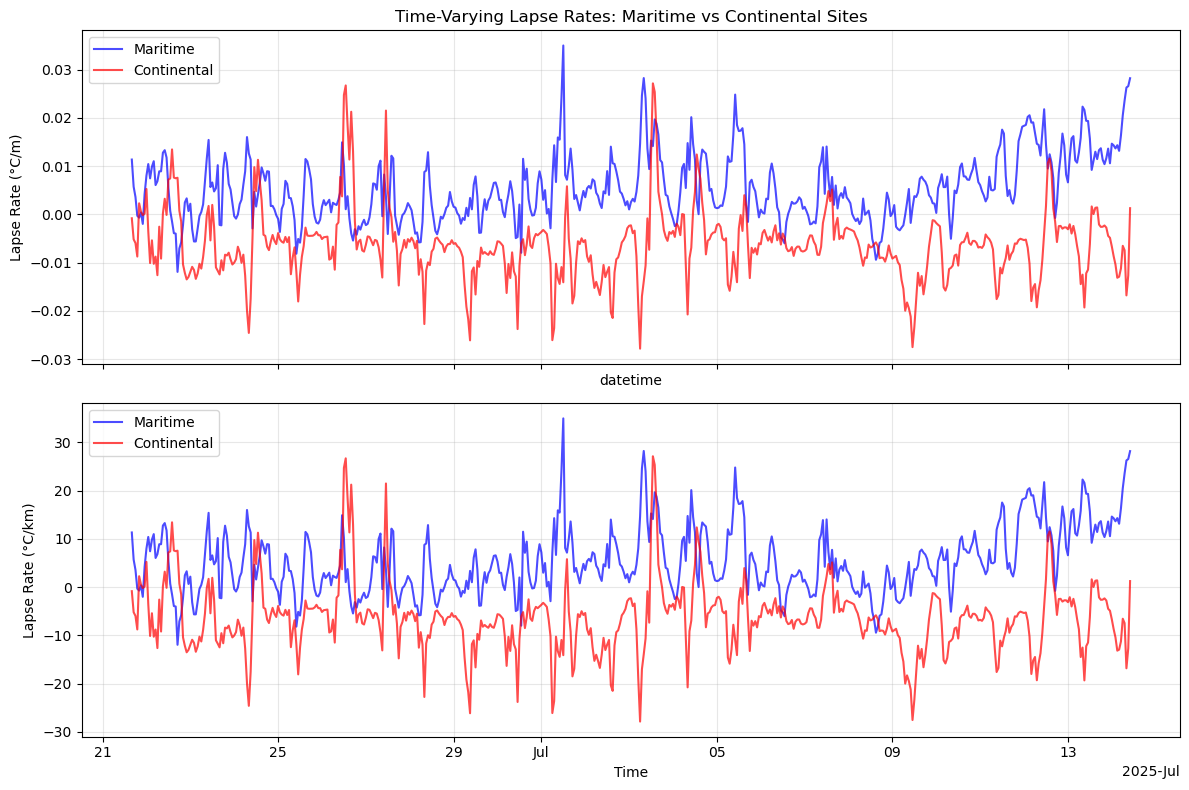

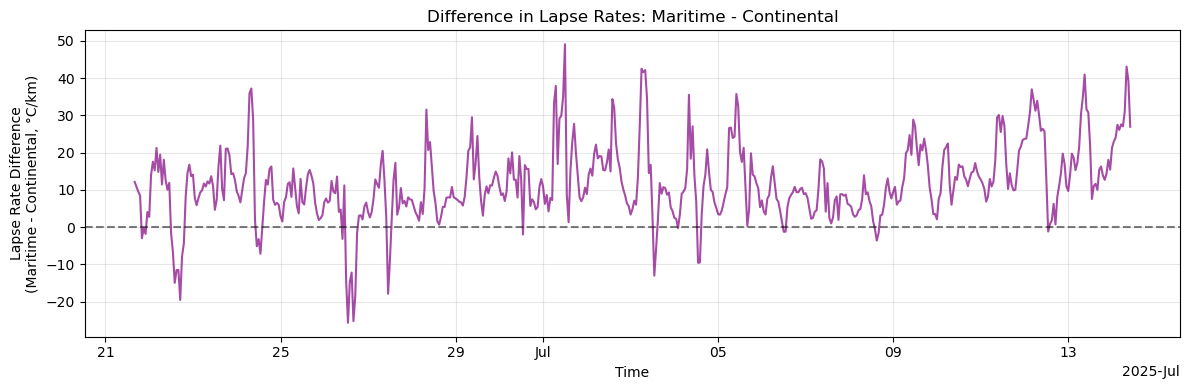

In [ ]:
# Create time series plots of the lapse rates
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot lapse rates in °C/km for better readability
ax1 = axes[0]
ds_hourly.maritime_lapse_rate.plot(ax=ax1, label="Maritime", color="blue", alpha=0.7)
ds_hourly.continental_lapse_rate.plot(
    ax=ax1, label="Continental", color="red", alpha=0.7
)
ax1.set_ylabel("Lapse Rate (°C/m)")
ax1.set_title("Time-Varying Lapse Rates: Maritime vs Continental Sites")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Convert to °C/km and plot
ax2 = axes[1]
(ds_hourly.maritime_lapse_rate * 1000).plot(
    ax=ax2, label="Maritime", color="blue", alpha=0.7
)
(ds_hourly.continental_lapse_rate * 1000).plot(
    ax=ax2, label="Continental", color="red", alpha=0.7
)
ax2.set_ylabel("Lapse Rate (°C/km)")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also plot the difference between maritime and continental lapse rates
fig, ax = plt.subplots(figsize=(12, 4))
lapse_diff = (ds_hourly.maritime_lapse_rate - ds_hourly.continental_lapse_rate) * 1000
lapse_diff.plot(ax=ax, color="purple", alpha=0.7)
ax.axhline(y=0, color="black", linestyle="--", alpha=0.5)
ax.set_ylabel("Lapse Rate Difference\n(Maritime - Continental, °C/km)")
ax.set_xlabel("Time")
ax.set_title("Difference in Lapse Rates: Maritime - Continental")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()